#***Introduction to Data Science (AI11002)***
##*Class Project -- Team 1*
* Ayan Rakshit (25AI10023)
* P. V. Pradeep Lokesh (25AI10040)
* Sounak Banerjee (25AI10047)

*Date of Submission: 24th March 2026*

> "Never doubt that a small group of thoughtful, committed citizens can change the world; indeed, it's the only thing that ever has."
>
> — **Margaret Mead**

#*Our Data Science Project* :

###**Green Horizons: Decoding Global Energy Consumption, Sustainable Development and GDP**

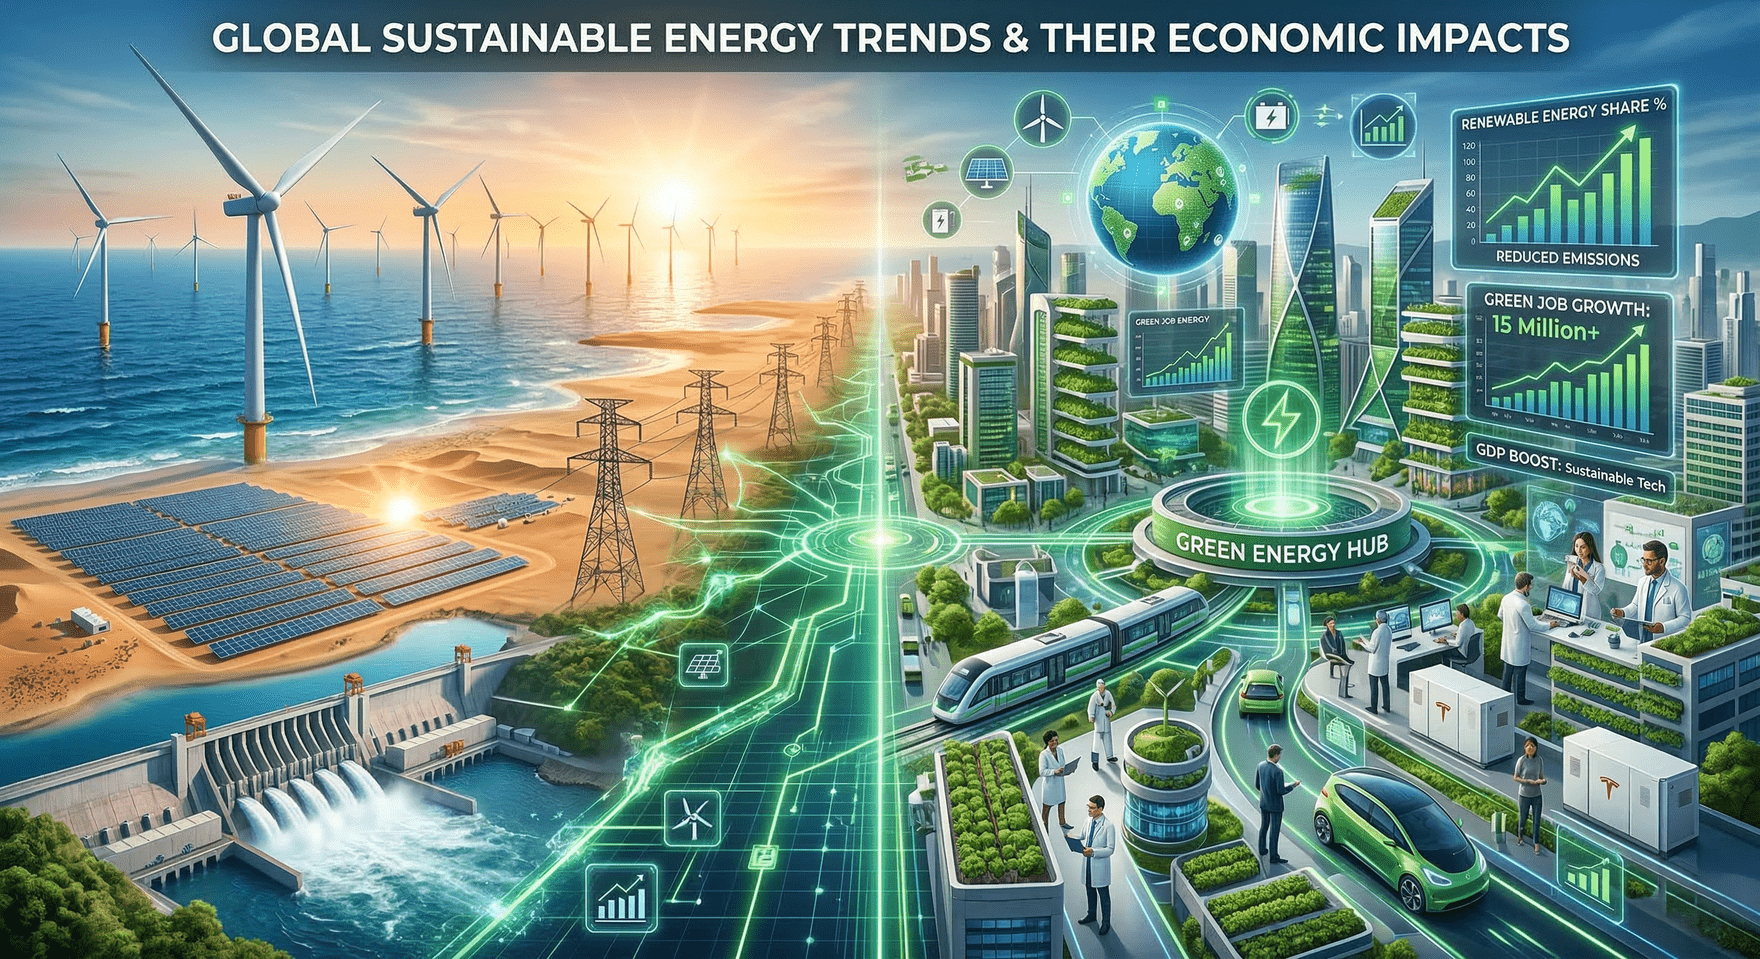

In this project, we will be analyzing global sustainable energy trends and their economic impacts using the dataset from "anshtanwar/global-data-on-sustainable-energy", obtained from Kaggle. The analysis includes:
1. **Data Cleaning & Pre-processing**: Handling missing values and formatting numerical columns for energy and economic metrics, by filling them using regression analysis.
2. **Correlation Analysis**: Generating a Seaborn heatmap to identify relationships between energy metrics (e.g., renewable share, energy intensity) and GDP per capita.
3. **Renewable Growth**: We calculated and visualized year-over-year growth in renewable electricity generating capacity per capita for top-performing countries.
4. **Green Economy Metrics**: Ranking of countries by renewable energy share and evaluate the 'Green Economy' by comparing energy intensity levels against GDP per capita.
5. **Comprehensive Visualization**: We created time-series plots comparing CO2 emissions trends against renewable energy adoption and a categorical performance analysis of renewable energy shares.
6. **Further Questions**: Using the engineered data, we tried to answer the following questions:


> *   **Which are the top 15 developing countries to achieve 100% electricity acces?**
> *   **Energy Kuznets Curve: How does the CO2 emission from each country depend on its rising GDP per capita?**
> *   **Carbon Neutrality: When will each country start generating 50% of its energy from renewable sources?**







#Loading the Dataset

In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd

# Load the dataset directly into a pandas DataFrame
# The second argument is the dataset identifier
# The third argument is the specific file name within that dataset
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "anshtanwar/global-data-on-sustainable-energy",
    "global-data-on-sustainable-energy (1).csv"
)

# Display the first few rows
print(df.head())

/tmp/ipykernel_5125/3707668593.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 502k/502k [00:00<00:00, 3.60MB/s]


        Entity  Year  Access to electricity (% of population)  \
0  Afghanistan  2000                                 1.613591   
1  Afghanistan  2001                                 4.074574   
2  Afghanistan  2002                                 9.409158   
3  Afghanistan  2003                                14.738506   
4  Afghanistan  2004                                20.064968   

   Access to clean fuels for cooking  \
0                                6.2   
1                                7.2   
2                                8.2   
3                                9.5   
4                               10.9   

   Renewable-electricity-generating-capacity-per-capita  \
0                                               9.22      
1                                               8.86      
2                                               8.47      
3                                               8.09      
4                                               7.75      

   Financial 

In [2]:
df.describe()

,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Land Area(Km2),Latitude,Longitude
count,3649.000000,3639.000000,3480.000000,2718.000000,1.560000e+03,3455.000000,3628.000000,3523.000000,3628.000000,3607.000000,3649.000000,3442.000000,3.221000e+03,1512.000000,3332.000000,3367.000000,3.648000e+03,3648.000000,3648.000000
mean,2010.038367,78.933702,63.255287,113.137498,9.422400e+07,32.638165,70.365003,13.450190,23.968010,36.801182,25743.981745,5.307345,1.598665e+05,11.986707,3.441610,13283.774348,6.332135e+05,18.246388,14.822695
std,6.054228,30.275541,39.043658,244.167256,2.981544e+08,29.894901,348.051866,73.006623,104.431085,34.314884,34773.221366,3.532020,7.736611e+05,14.994644,5.686720,19709.866716,1.585519e+06,24.159232,66.348148
min,2000.000000,1.252269,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.110000,1.000000e+01,0.000000,-62.075920,111.927225,2.100000e+01,-40.900557,-175.198242
25%,2005.000000,59.800890,23.175000,3.540000,2.600000e+05,6.515000,0.290000,0.000000,0.040000,2.877847,3116.737300,3.170000,2.020000e+03,2.137095,1.383302,1337.813437,2.571300e+04,3.202778,-11.779889
50%,2010.000000,98.361570,83.150000,32.910000,5.665000e+06,23.300000,2.970000,0.000000,1.470000,27.865068,13120.570000,4.300000,1.050000e+04,6.290766,3.559855,4578.633208,1.176000e+05,17.189877,19.145136
75%,2015.000000,100.000000,100.000000,112.210000,5.534750e+07,55.245000,26.837500,0.000000,9.600000,64.403792,33892.780000,6.027500,6.058000e+04,16.841638,5.830099,15768.615365,5.131200e+05,38.969719,46.199616
max,2020.000000,100.000000,100.000000,3060.190000,5.202310e+09,96.040000,5184.130000,809.410000,2184.940000,100.000010,262585.700000,32.570000,1.070722e+07,86.836586,123.139555,123514.196700,9.984670e+06,64.963051,178.065032


# Data Preparation and Cleaning

Cleaning the dataset by handling missing values and ensuring numerical columns are correctly formatted for analysis.


## Data Cleaning with Regression Imputation

Loading the dataset, standardizing column names, dropping columns with excessive missing values, and then applying regression imputation for the remaining numerical missing values.


In [3]:
import numpy as np
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# 1. Reload the dataset
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "anshtanwar/global-data-on-sustainable-energy",
    "global-data-on-sustainable-energy (1).csv"
)
print("Dataset reloaded successfully.")

# 2. Standardize column names
df.columns = df.columns.str.replace('\n', ' ', regex=False).str.strip().str.replace('  ', ' ')
print("Column names standardized.")

# 3. Calculate missing values and drop columns with > 50% missing data
missing_values_count = df.isnull().sum()
limit = len(df) * 0.5
columns_to_drop = missing_values_count[missing_values_count > limit].index.tolist()

if columns_to_drop:
    df.drop(columns=columns_to_drop, inplace=True)
    print(f"Dropped columns with > 50% missing values: {columns_to_drop}")
else:
    print("No columns dropped due to excessive missing values.")

# Ensure all columns are numeric where appropriate before imputation
# This is crucial for IterativeImputer to work correctly
for col in df.columns:
    # Exclude non-numeric columns like 'Entity'
    if df[col].dtype == 'object' and col not in ['Entity']:
        try:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        except:
            pass # Keep as object if conversion fails

# 4. Create a list of numerical columns that still contain missing values
numerical_cols_with_nan = df.select_dtypes(include=np.number).columns[df.select_dtypes(include=np.number).isnull().any()].tolist()

if numerical_cols_with_nan:
    print(f"Numerical columns with remaining missing values: {numerical_cols_with_nan}")

    # 5. Instantiate and apply IterativeImputer
    imputer = IterativeImputer(random_state=0)
    imputed_data = imputer.fit_transform(df[numerical_cols_with_nan])

    # Convert back to DataFrame and update original df
    df[numerical_cols_with_nan] = pd.DataFrame(imputed_data, columns=numerical_cols_with_nan, index=df.index)
    print("Remaining numerical missing values imputed using IterativeImputer.")
else:
    print("No remaining numerical missing values to impute.")

print("\nMissing values after imputation:\n", df.isnull().sum().sum()) # Should be 0 if all numerical NaNs handled
print("Data cleaning with regression imputation completed successfully.")

/tmp/ipykernel_5125/2543016188.py:9: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'global-data-on-sustainable-energy' dataset.
Dataset reloaded successfully.
Column names standardized.
Dropped columns with > 50% missing values: ['Financial flows to developing countries (US $)', 'Renewables (% equivalent primary energy)']
Numerical columns with remaining missing values: ['Access to electricity (% of population)', 'Access to clean fuels for cooking', 'Renewable-electricity-generating-capacity-per-capita', 'Renewable energy share in the total final energy consumption (%)', 'Electricity from fossil fuels (TWh)', 'Electricity from nuclear (TWh)', 'Electricity from renewables (TWh)', 'Low-carbon electricity (% electricity)', 'Energy intensity level of primary energy (MJ/$2017 PPP GDP)', 'Value_co2_emissions_kt_by_country', 'gdp_growth', 'gdp_per_capita', 'Density\\n(P/Km2)', 'Land Area(Km2)', 'Latitude', 'Longitude']
Remaining numerical missing values imputed using IterativeImputer.

Missing values after imputation:
 0
Data clean

#Exploratory Data Analysis (EDA)

## Correlation Analysis Heatmap 🎗️

---

Computing the correlation matrix for the energy and economic metrics using the cleaned data, and visualizing it with a Seaborn heatmap to identify relationships between key variables.


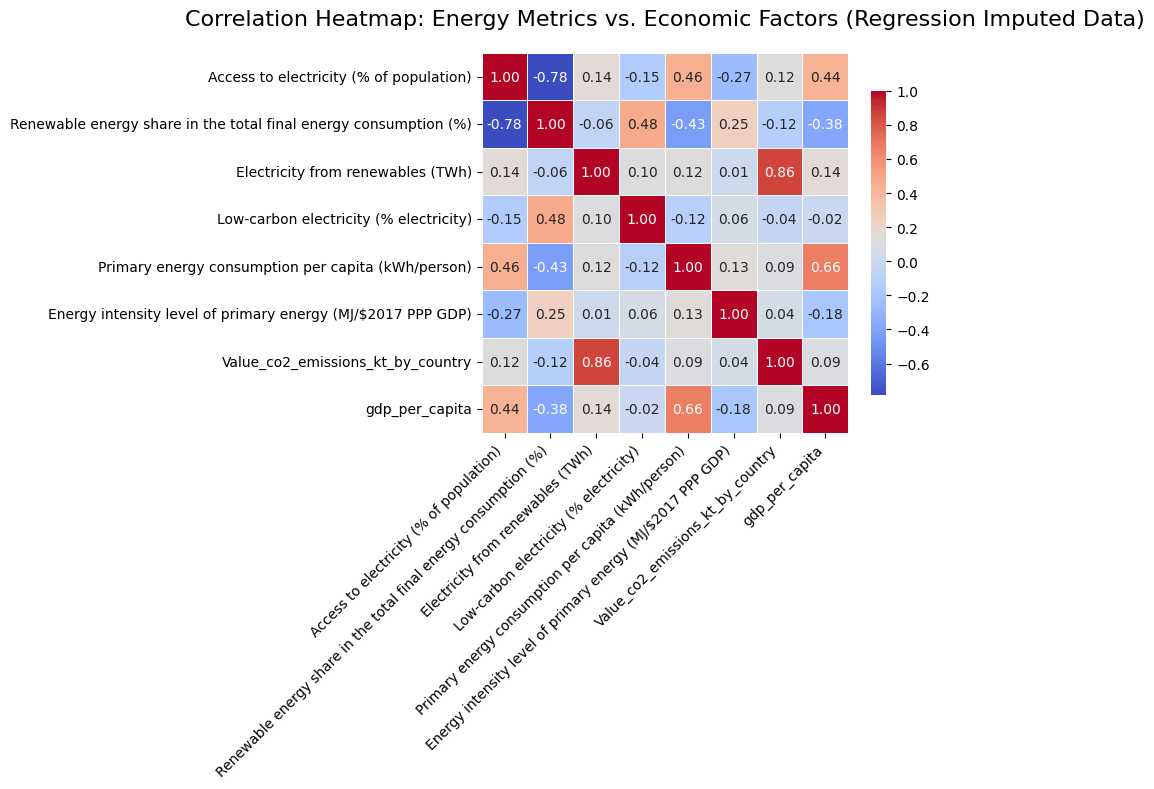

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define the subset of relevant numerical columns
selected_columns = ['Access to electricity (% of population)',
    'Renewable energy share in the total final energy consumption (%)',
    'Electricity from renewables (TWh)',
    'Low-carbon electricity (% electricity)',
    'Primary energy consumption per capita (kWh/person)',
    'Energy intensity level of primary energy (MJ/$2017 PPP GDP)',
    'Value_co2_emissions_kt_by_country',
    'gdp_per_capita'
  ]

# Ensure only existing columns in df are used and all are numeric
existing_cols = [col for col in selected_columns if col in df.columns]

# 2. Calculate the Pearson correlation matrix
corr_matrix = df[existing_cols].corr()

# 3. Create the heatmap
plt.figure(figsize=(9.6, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'shrink': .8}
)

# 4. Add title and display
plt.title('Correlation Heatmap: Energy Metrics vs. Economic Factors (Regression Imputed Data)', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

From this Correlation Heatmap, we get to know about few relations:

> 1. We got strong positive correlation between CO2 emmision and Electricity generated from renewables. This is a classic case of 'Correlation does not imply Causation'.
> 2. As expected GDP-per-Capita is pretty well correlated to Per-Capita energy consumption.
> 3. Values close to zero imply almost no correlation.
> 4. There are strong neagtive correlations between Renewable energyv share and access to electricity ( which in turn is positively correlated to GDP per-capita and per capita energy consumption )


## Rankings and Green Economy Metrics

Ranking of countries based on their renewable energy share and analyzing the relationship between energy intensity and GDP per capita to evaluate the 'Green Economy'.


In [5]:
import plotly.express as px

# 1. Aggregate to find the mean renewable energy share per country
ren_share_col = 'Renewable energy share in the total final energy consumption (%)'
energy_intensity_col = 'Energy intensity level of primary energy (MJ/$2017 PPP GDP)'

country_rankings = df.groupby('Entity')[ren_share_col].mean().sort_values(ascending=False)

# 2. Identify top 10 countries
top_10_renewable = country_rankings.head(10)

top_10_renewable_df = top_10_renewable.reset_index()
top_10_renewable_df.columns = ['Entity', 'Average Renewable Energy Share (%)']

fig = px.bar(
    top_10_renewable_df,
    x='Average Renewable Energy Share (%)',
    y='Entity',
    orientation='h',
    title='Interactive: Top 10 Countries by Average Renewable Energy Share (%)',
    labels={'Average Renewable Energy Share (%)': 'Average Renewable Energy Share (%)', 'Entity': 'Country'},
    color='Average Renewable Energy Share (%)',
    color_continuous_scale='plasma'
)
fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.update_xaxes(range=[80, 100])
fig.show()

###We have simply shown the top 10 countries  with the highest renewable energ share. Curiously none of these are well developed countries because the renewable energy used here mostly comes from bio-fuel or the natural resources they have, not indicating a developed energy infrastructure.

## Green Economy Scatter Plot (Interactive Plotly)

Converting the 'Green Economy Scatter' plot (Energy Intensity vs. GDP per Capita) to an interactive Plotly scatter plot, based on the regression-imputed dataset.

In [6]:
import plotly.express as px

energy_intensity_col = 'Energy intensity level of primary energy (MJ/$2017 PPP GDP)'

# Create an interactive scatter plot for Green Economy evaluation
fig_scatter = px.scatter(
    df,
    x=energy_intensity_col,
    y='gdp_per_capita',
    color='Year',
    log_y=True, # Apply logarithmic scale to y-axis
    title='Interactive: Green Economy Analysis: Energy Intensity vs. GDP per Capita',
    labels={
        energy_intensity_col: 'Energy Intensity (MJ/$2017 PPP GDP)',
        'gdp_per_capita': 'GDP per Capita (Log Scale)',
        'Year': 'Year'
    },
    hover_data={'Entity': True, energy_intensity_col: ':.2f', 'gdp_per_capita': ':.2f'}
)

fig_scatter.update_layout(
    xaxis_title='Energy Intensity (MJ/$2017 PPP GDP)',
    yaxis_title='GDP per Capita (Log Scale)',
    hovermode='closest'
)

fig_scatter.show()

## Renewable Capacity Growth Analysis (Interactive Plotly)

Converting the 'Renewable Capacity Growth' plot from Matplotlib/Seaborn to an interactive Plotly line plot, based on the regression-imputed dataset.

In [7]:
import plotly.express as px
import numpy as np

# 1. Sort the DataFrame by Entity and Year (if not already sorted)
df = df.sort_values(by=['Entity', 'Year'])

# 2. Calculate YoY percentage change for renewable capacity per capita
capacity_col = 'Renewable-electricity-generating-capacity-per-capita'
df['Capacity_Growth_Rate'] = df.groupby('Entity')[capacity_col].pct_change() * 100

# Handle infinite values and division by zero
df['Capacity_Growth_Rate'] = df['Capacity_Growth_Rate'].replace([np.inf, -np.inf], np.nan)

# 3. Identify top 5 countries with highest average growth rate
avg_growth = df.groupby('Entity')['Capacity_Growth_Rate'].mean().sort_values(ascending=False)
top_5_countries = avg_growth.head(5).index.tolist()

# 4. Filter data for these top 5 countries
top_growth_df = df[df['Entity'].isin(top_5_countries)].copy()

# 5. Create an interactive time-series line plot using Plotly Express
fig_growth = px.line(
    top_growth_df,
    x='Year',
    y='Capacity_Growth_Rate',
    color='Entity',
    markers=True,
    title='Growth in Renewable Electricity Generating Capacity (Top 5 Countries)',
    labels={
        'Year': 'Year',
        'Capacity_Growth_Rate': 'Growth Rate (%)',
        'Entity': 'Country'
    },
    hover_data={
        'Renewable-electricity-generating-capacity-per-capita': ':.2f',
        'Capacity_Growth_Rate': ':.2f'
    }
)

fig_growth.update_layout(
    xaxis_title='Year',
    yaxis_title='Growth Rate (%)',
    hovermode='x unified',
    xaxis_range=[2005, 2021]
)

fig_growth.show()

###Some of these countries show a sudden jump in renewable energy generating capacity probably due to a "low-base effect" that is when the existing capacity is so low that a small change causes a big percentage growth.

## GDP by Performance Tier Box Plot (Interactive Plotly)

Converting the 'GDP by Performance Tier Box Plot' from Matplotlib/Seaborn to an interactive Plotly visualization.

In [8]:
import plotly.express as px
import pandas as pd
import numpy as np

# 1. Categorize countries into performance tiers (re-run to ensure df state)
ren_col = 'Renewable energy share in the total final energy consumption (%)'
country_avg_ren = df.groupby('Entity')[ren_col].mean().dropna()

# Using qcut to create 3 tiers: Low, Medium, High
labels = ['Low', 'Medium', 'High']
performance_tiers = pd.qcut(country_avg_ren, q=3, labels=labels).to_frame(name='Performance_Tier')

# Merge tiers back to the main dataframe (or a snapshot for visualization)
viz_df = df.merge(performance_tiers, on='Entity', how='left')

custom_colors = {
    'Low': 'pink',
    'Medium': 'red',
    'High': 'brown'
}

# 2. Create an interactive box plot of GDP per capita across tiers
fig_box = px.box(
    viz_df,
    x='Performance_Tier',
    y='gdp_per_capita',
    title='GDP per Capita Distribution by Renewable Energy Performance Tier',
    labels={
        'Performance_Tier': 'Renewable Energy Performance Tier',
        'gdp_per_capita': 'GDP per Capita (Log Scale)'
    },
    category_orders={'Performance_Tier': ['Low', 'Medium', 'High']},
    log_y=True, # Apply logarithmic scale to y-axis
    color='Performance_Tier', # Color boxes by performance tier
    color_discrete_map=custom_colors # Use a color sequence
)

fig_box.update_layout(
    xaxis_title='Renewable Energy Performance Tier',
    yaxis_title='GDP per Capita (Log Scale)',
    hovermode='x unified'
)

fig_box.show()

## CO2 vs Renewable Share Time-series (Interactive)

'CO2 vs Renewable Share Time-series' plot using an interactive Plotly visualization.

In [9]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# 1. Calculate global annual means (re-run as df might have been modified in between)
global_trends = df.groupby('Year').agg({
    'Value_co2_emissions_kt_by_country': 'mean',
    'Renewable energy share in the total final energy consumption (%)': 'mean'
}).reset_index()

# 2. Dual-axis time-series plot using Plotly Graph Objects
fig_co2_renew = go.Figure()

# Add CO2 Emissions trace
fig_co2_renew.add_trace(go.Scatter(
    x=global_trends['Year'],
    y=global_trends['Value_co2_emissions_kt_by_country'],
    mode='lines+markers',
    name='Avg CO2 Emissions (kt)',
    yaxis='y1',
    line=dict(color='red') # Changed from 'tab:red' to 'red'
))

# Add Renewable Share trace
fig_co2_renew.add_trace(go.Scatter(
    x=global_trends['Year'],
    y=global_trends['Renewable energy share in the total final energy consumption (%)'],
    mode='lines+markers',
    name='Avg Renewable Energy Share (%)',
    yaxis='y2',
    line=dict(color='green') # Changed from 'tab:green' to 'green'
))

# Update layout for dual Y-axes
fig_co2_renew.update_layout(
    title='Interactive: Global Trends: CO2 Emissions vs. Renewable Energy Adoption',
    xaxis=dict(title='Year', dtick=1),
    yaxis=dict(
        title='Avg CO2 Emissions (kt)',
        titlefont=dict(color='red'),
        tickfont=dict(color='red')
    ),
    yaxis2=dict(
        title='Avg Renewable Energy Share (%)',
        titlefont=dict(color='green'),
        tickfont=dict(color='green'),
        overlaying='y',
        side='right'
    ),
    hovermode='x unified'
)

fig_co2_renew.show()

###Global trends show an increase in CO2 emmision and a decreasing renewable energy share inspite of increase in climate awareness probably because developing countries move away from bio-fuel to fossil-fuels to fulfill increasing energy demands. Keep in mind that some of these values are the result of imputation for example in 2020 very few countries had provided relevant data so we had to use Regressive imputation.

# Electricity access trends for selected top countries (from top 15)
We will now analyze, predict and interprete with the bar charts for 'Top 15 Debveloping Countries Predicted to Achieve 100% Electricity Access Earliest' and 'Top 10 Countries by Average Renewable Energy Share', and the time-series plot for 'Electricity Access Trends and Projections for Selected Countries' to be interactive using Plotly Express. Then, we'll summarize the updated interactive visualizations and confirm their functionality.

## Analysis and Interpretation of Predictions

Analyzing the predictions to identify patterns, highlighting countries making significant progress, and interpreting the role of electricity access growth and GDP growth in achieving full access.


#Prediction for 100% Electricity Access

## Data Preparation for Prediction

Preparing the dataset for prediction by ensuring all necessary columns ('Access to electricity (% of population)', 'gdp_growth') are clean and suitable for analysis. This includes calculating the year-over-year growth rate for electricity access. We made an assumption that all countries in the dataset are 'developing' for the purpose of this analysis, or filtered based on an internal proxy if available, explaining any such assumptions.


In [10]:
import numpy as np

# 1. Ensure the DataFrame df is sorted by 'Entity' and 'Year'
df = df.sort_values(by=['Entity', 'Year']).copy()

# 2. Calculate the year-over-year percentage change for 'Access to electricity (% of population)'
# 3. Store this calculated growth rate in a new column 'Electricity_Access_Growth_Rate'
df['Electricity_Access_Growth_Rate'] = df.groupby('Entity')['Access to electricity (% of population)'].pct_change() * 100

# 4. Handle any infinite values (which can result from division by zero) by replacing them with np.nan
df['Electricity_Access_Growth_Rate'] = df['Electricity_Access_Growth_Rate'].replace([np.inf, -np.inf], np.nan)

# 5. Confirm that the gdp_growth column is suitable for analysis (already imputed)
# Display descriptive statistics for gdp_growth to quickly check for any unexpected values or NaNs.
print("\nDescriptive statistics for 'gdp_growth' column:")
print(df['gdp_growth'].describe())

print("\nFirst 5 rows of the DataFrame with new 'Electricity_Access_Growth_Rate' column:")
print(df[['Entity', 'Year', 'Access to electricity (% of population)', 'Electricity_Access_Growth_Rate', 'gdp_growth']].head())

print("\nData preparation for prediction completed. 'Electricity_Access_Growth_Rate' column added and checked.")


Descriptive statistics for 'gdp_growth' column:
count    3649.000000
mean        3.438612
std         5.441795
min       -62.075920
25%         1.649902
50%         3.511164
75%         5.543639
max       123.139555
Name: gdp_growth, dtype: float64

First 5 rows of the DataFrame with new 'Electricity_Access_Growth_Rate' column:
        Entity  Year  Access to electricity (% of population)  \
0  Afghanistan  2000                                 1.613591   
1  Afghanistan  2001                                 4.074574   
2  Afghanistan  2002                                 9.409158   
3  Afghanistan  2003                                14.738506   
4  Afghanistan  2004                                20.064968   

   Electricity_Access_Growth_Rate  gdp_growth  
0                             NaN    5.008534  
1                      152.515910    4.965390  
2                      130.923724    5.094426  
3                       56.640010    8.832278  
4                       36.139769    1

## Predictive Modeling for Electricity Access

Developping a model to predict the year each country achieves 100% electricity access. This involves analyzing historical trends for 'Access to electricity (% of population)' and 'gdp_growth' for each country. A linear extrapolation based on recent average growth rates for electricity access is employed, considering the complexities of modeling this growth curve. Cases where a country already has 100% access or exhibits negative growth has been handled.


In [11]:
import pandas as pd
import numpy as np

# 1. For each country, extract the most recent 'Year', 'Access to electricity (% of population)',
#    and 'Electricity_Access_Growth_Rate'.
#    Sort by year descending to easily get the most recent data.
df_latest = df.sort_values(by=['Entity', 'Year'], ascending=[True, False]).drop_duplicates(subset=['Entity'])

# Handle cases where Electricity_Access_Growth_Rate might be NaN after drop_duplicates due to no previous year
# For such cases, we can choose to impute with a global mean, or treat as 'Unlikely with current trend' if there's no info.
# For now, we'll keep NaN and handle it in the prediction logic, potentially falling into 'Unlikely' if no valid growth is found.

# 2. Initialize a new DataFrame to store the predicted year to 100% electricity access for each country.
predicted_access_years = pd.DataFrame(columns=['Entity', 'Predicted_Year_100_Access'])

# 3. Iterate through each country's latest data:
predictions = []
for index, row in df_latest.iterrows():
    entity = row['Entity']
    latest_year = row['Year']
    access_percentage = row['Access to electricity (% of population)']
    growth_rate = row['Electricity_Access_Growth_Rate']

    predicted_year = None

    # a. If a country's 'Access to electricity (% of population)' is already 100% or greater, mark its predicted year as 'Achieved'.
    if access_percentage >= 100:
        predicted_year = 'Achieved'
    # b. If a country's 'Electricity_Access_Growth_Rate' is negative or zero, mark its predicted year as 'Unlikely with current trend'.
    elif pd.isna(growth_rate) or growth_rate <= 0:
        predicted_year = 'Unlikely with current trend'
    # c. For countries with positive growth:
    else:
        # i. Calculate the remaining percentage needed to reach 100% access.
        remaining_percentage = 100 - access_percentage

        # ii. Calculate the number of years required using the formula: years_needed = remaining_percentage / growth_rate.
        # Ensure growth_rate is not zero to prevent division by zero, though already checked for <= 0
        if growth_rate > 0:
            years_needed = remaining_percentage / (growth_rate / 100) # Convert growth_rate back to a decimal for calculation

            # iii. Add the years_needed to the latest_year to determine the predicted year of achievement.
            predicted_year = round(latest_year + years_needed)
        else: # Should not be reached given previous checks, but as a safeguard
            predicted_year = 'Unlikely with current trend'

    predictions.append({'Entity': entity, 'Predicted_Year_100_Access': predicted_year})

# 4. Store these predictions in a structured format, for example, a new DataFrame named predicted_access_years
predicted_access_years = pd.DataFrame(predictions)

print("Predicted years for 100% electricity access:")
print(predicted_access_years.head(10))
print(predicted_access_years.tail(10))

Predicted years for 100% electricity access:
                Entity    Predicted_Year_100_Access
0          Afghanistan  Unlikely with current trend
1              Albania                     Achieved
2              Algeria                         2084
3               Angola                         3963
4  Antigua and Barbuda                     Achieved
5            Argentina                     Achieved
6              Armenia                     Achieved
7                Aruba                     Achieved
8            Australia                     Achieved
9              Austria                     Achieved
                   Entity Predicted_Year_100_Access
166               Ukraine                  Achieved
167  United Arab Emirates                  Achieved
168        United Kingdom                  Achieved
169         United States                  Achieved
170               Uruguay                  Achieved
171            Uzbekistan                  Achieved
172               V

## Visualization of Prediction Results

Visualizing the prediction results to illustrate when each country is projected to achieve 100% electricity access. This includes a bar chart for the top N countries predicted to reach this milestone earliest, and potentially a time-series plot for a few selected countries showcasing their current access levels and projected paths.


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Filter the predicted_access_years DataFrame for numeric predicted years
numeric_predictions = predicted_access_years[pd.to_numeric(predicted_access_years['Predicted_Year_100_Access'], errors='coerce').notna()].copy()
numeric_predictions['Predicted_Year_100_Access'] = pd.to_numeric(numeric_predictions['Predicted_Year_100_Access'])

# 2. Sort this filtered DataFrame to identify the top 15 countries predicted to achieve 100% electricity access earliest.
top_15_earliest = numeric_predictions.sort_values(by='Predicted_Year_100_Access').head(15)

# 4. Select a few diverse countries for time-series visualization
selected_countries = {
    'Achieved': 'Albania',
    'Early Numeric': 'Peru', # From top_15_earliest
    'Late Numeric': 'Zimbabwe', # From predicted_access_years.tail()
    'Unlikely': 'Afghanistan'
}

print("Top 15 Countries Predicted to Achieve 100% Electricity Access Earliest:")

Top 15 Countries Predicted to Achieve 100% Electricity Access Earliest:


## Interactive Bar Chart

We generated the bar charts for 'Top 15 Developing Countries Predicted to Achieve 100% Electricity Access Earliest' using Plotly Express to include interactive features like hover effects.


In [13]:
import plotly.express as px

# 1. For the 'Top 15 Countries Predicted to Achieve 100% Electricity Access Earliest' bar chart:
fig1 = px.bar(
    top_15_earliest,
    x='Predicted_Year_100_Access',
    y='Entity',
    orientation='h',
    title='Interactive: Top 15 Countries Predicted to Achieve 100% Electricity Access Earliest',
    labels={'Predicted_Year_100_Access': 'Predicted Year for 100% Access', 'Entity': 'Country'},
    color='Predicted_Year_100_Access',
    color_continuous_scale='viridis'
)
fig1.update_layout(yaxis={'categoryorder':'total descending'})
fig1.update_xaxes(range=[2000, 2400])
fig1.show()

###Electricity Access Trends and Projections for Selected Countries

In [14]:
import plotly.graph_objects as go

# Select the same countries as in the previous time-series plot
selected_countries = {
    'Achieved': 'Albania',
    'Early Numeric': 'Peru', # From top_15_earliest
    'Late Numeric': 'Zimbabwe', # From predicted_access_years.tail()
    'Unlikely': 'Afghanistan'
}

# Retrieve their historical 'Access to electricity (% of population)'
time_series_data = df[df['Entity'].isin(selected_countries.values())].copy()

fig_ts = go.Figure()

colors = px.colors.qualitative.Plotly # Use a qualitative color scale for distinct countries

for i, (status, country) in enumerate(selected_countries.items()):
    country_data = time_series_data[time_series_data['Entity'] == country]
    predicted_info = predicted_access_years[predicted_access_years['Entity'] == country].iloc[0]

    current_color = colors[i % len(colors)]

    # Plot historical data
    fig_ts.add_trace(go.Scatter(
        x=country_data['Year'],
        y=country_data['Access to electricity (% of population)'],
        mode='lines+markers',
        name=f'{country} (Historical)',
        line=dict(color=current_color)
    ))

    # Plot projected path if numeric prediction exists
    if isinstance(predicted_info['Predicted_Year_100_Access'], (int, float)):
        last_year = country_data['Year'].max()
        last_access = country_data['Access to electricity (% of population)'].iloc[-1]
        predicted_year = predicted_info['Predicted_Year_100_Access']

        # Create projection points
        projection_years = [last_year, predicted_year]
        projection_access = [last_access, 100]

        fig_ts.add_trace(go.Scatter(
            x=projection_years,
            y=projection_access,
            mode='lines+markers',
            name=f'{country} (Projected)',
            line=dict(dash='dash', color=current_color)
        ))

# Add 100% access target line
fig_ts.add_hline(y=100, line_dash="dot", line_color="grey", annotation_text="100% Access Target",
                annotation_position="bottom right", name='100% Access Target')

fig_ts.update_layout(
    title='Electricity Access Trends and Projections for Selected Countries',
    xaxis_title='Year',
    yaxis_title='Access to electricity (% of population)',
    hovermode='x unified', # Unify hover data for better comparison
    xaxis=dict(range=[2000, 2100]), # Extend x-axis to cover future predictions
    yaxis=dict(range=[-5, 110]) # Ensure 100% is visible and a bit of buffer
)

fig_ts.show()

# EKC (Energy Kuznets Curve)

A well known concept among environmental economists is the EKC: Energy Kuznets Curve. The theory behind it basically says that an underdeveloped country has very few industries and thus low Carbon dioxide (CO2) emission. As the country develops, economic activites contribute to a gradual rise in CO2 emission. However, once the country has reached a certain thershold of development, it begins investing in environment-friendly energy alternatives (e.g., solar, wind, hydro and nuclear power), causing an eventual decrease in CO2 emission.

Since the time period required to observe this change is quite large and outside the scope of our current dataset, we have chosen 5 countries in different developmental stages and have visualised the variation of CO2 emission with GDP per capita for them (2000-2020). The result is a series of "fractured" EKC, that is, different stages of the EKC.

Prepare the dataset by selecting the columns 'Entity', 'Year', 'gdp_per_capita', 'Value_co2_emissions_kt_by_country', and 'Renewable energy share in the total final energy consumption (%)' for Environmental Kuznets Curve (EKC) visualization.

## Data Preparation for EKC Visualization

Preparation of the dataset by selecting the necessary columns: 'Entity', 'Year', 'gdp_per_capita', 'Value_co2_emissions_kt_by_country', and 'Renewable energy share in the total final energy consumption (%).'


In [15]:
import pandas as pd

# 1. Create a new DataFrame, ekc_df, by selecting the necessary columns
ekc_df = df[['Entity', 'Year', 'gdp_per_capita', 'Value_co2_emissions_kt_by_country', 'Renewable energy share in the total final energy consumption (%)']].copy()

# 2. Display the first few rows of the new ekc_df DataFrame to verify the selection
print("First few rows of the new EKC DataFrame:")
print(ekc_df.head())

First few rows of the new EKC DataFrame:
        Entity  Year  gdp_per_capita  Value_co2_emissions_kt_by_country  \
0  Afghanistan  2000     6727.451059                         760.000000   
1  Afghanistan  2001     7303.593374                         730.000000   
2  Afghanistan  2002      179.426579                        1029.999971   
3  Afghanistan  2003      190.683814                        1220.000029   
4  Afghanistan  2004      211.382074                        1029.999971   

   Renewable energy share in the total final energy consumption (%)  
0                                              44.99                 
1                                              45.60                 
2                                              37.83                 
3                                              36.66                 
4                                              44.24                 


## Interactive EKC Visualization

Creating an interactive scatter plot using Plotly Express. The plot will display 'gdp_per_capita' on the x-axis, 'Value_co2_emissions_kt_by_country' on the y-axis, and use 'Renewable energy share in the total final energy consumption (%)' to color the data points. The plot will also be animated by 'Year' to show trends over time.


In [16]:
import plotly.express as px

# Create an interactive scatter plot for EKC visualization
fig_ekc = px.scatter(
    ekc_df,
    x='gdp_per_capita',
    y='Value_co2_emissions_kt_by_country',
    color='Renewable energy share in the total final energy consumption (%)',
    animation_frame='Year',
    hover_name='Entity',
    log_x=True,
    log_y=True,
    size_max=60,
    title='Interactive EKC Visualization: CO2 Emissions vs. GDP per Capita (Animated by Year)',
    labels={
        'gdp_per_capita': 'GDP per Capita',
        'Value_co2_emissions_kt_by_country': 'CO2 Emissions (kt)',
        'Renewable energy share in the total final energy consumption (%)': 'Renewable Energy Share (%)'
    },
    color_continuous_scale=px.colors.sequential.Viridis
)

fig_ekc.update_layout(
    xaxis_title='GDP per Capita (Log Scale)',
    yaxis_title='CO2 Emissions (kt) (Log Scale)',
    hovermode='closest'
)

fig_ekc.show()

print("Interactive EKC Visualization created successfully.")

Interactive EKC Visualization created successfully.


## Animated India Dual-Axis Chart

Animating the dual-axis line chart for India to show year-wise progression, displaying CO2 emissions and renewable electricity against GDP per capita.


In [18]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np

# Reload the dataset to ensure 'df' is defined
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "anshtanwar/global-data-on-sustainable-energy",
    "global-data-on-sustainable-energy (1).csv"
)

# Filter data for India
df_india = df[df['Entity'] == 'India'].copy()

# df_india is already available from the previous step

# Create figure with dual y-axes
fig_india = make_subplots(specs=[[{"secondary_y": True}]])

# Define frames
frames = []
# Determine global min/max for axes to ensure consistent scaling across frames
x_min, x_max = df_india['gdp_per_capita'].min(), df_india['gdp_per_capita'].max()
y1_min, y1_max = df_india['Value_co2_emissions_kt_by_country'].min(), df_india['Value_co2_emissions_kt_by_country'].max()
y2_min, y2_max = df_india['Electricity from renewables (TWh)'].min(), df_india['Electricity from renewables (TWh)'].max()

for year in df_india['Year'].unique():
    frame_data = df_india[df_india['Year'] <= year] # Cumulative data up to current year

    co2_trace = go.Scatter(
        x=frame_data['gdp_per_capita'],
        y=frame_data['Value_co2_emissions_kt_by_country'],
        name='CO2 Emissions (kt)',
        mode='lines+markers',
        yaxis='y1',
        showlegend=True,
        line=dict(color='red')
    )

    renew_trace = go.Scatter(
        x=frame_data['gdp_per_capita'],
        y=frame_data['Electricity from renewables (TWh)'],
        name='Electricity from Renewables (TWh)',
        mode='lines+markers',
        yaxis='y2',
        showlegend=True,
        line=dict(color='green')
    )
    frames.append(go.Frame(data=[co2_trace, renew_trace], name=str(year)))

# Add initial traces (for the first year) - this will be the first frame
initial_year = df_india['Year'].min()
initial_data = df_india[df_india['Year'] == initial_year]

fig_india.add_trace(
    go.Scatter(x=initial_data['gdp_per_capita'], y=initial_data['Value_co2_emissions_kt_by_country'], name='CO2 Emissions (kt)', mode='lines+markers', line=dict(color='red')),
    secondary_y=False,
)
fig_india.add_trace(
    go.Scatter(x=initial_data['gdp_per_capita'], y=initial_data['Electricity from renewables (TWh)'], name='Electricity from Renewables (TWh)', mode='lines+markers', line=dict(color='green')),
    secondary_y=True,
)

# Add figure title and x-axis title
fig_india.update_layout(
    title_text='Animated: GDP Per Capita vs. CO2 Emissions and Renewable Electricity in India',
    xaxis_title='GDP Per Capita',
    yaxis=dict(
        title='CO2 Emissions (kt)',
        titlefont=dict(color='red'),
        tickfont=dict(color='red'),
        range=[y1_min, y1_max*7/6]
    ),
    yaxis2=dict(
        title='Electricity from Renewables (TWh)',
        titlefont=dict(color='green'),
        tickfont=dict(color='green'),
        overlaying='y',
        side='right',
        range=[y2_min, y2_max+50]
    ),
    xaxis=dict(
        range=[x_min, x_max]
    ),
    updatemenus=[{
        'buttons': [
            {
                'args': [None, {'frame': {'duration': 500, 'redraw': True}, 'fromcurrent': True, 'transition': {'duration': 300, 'easing': 'quadratic-in-out'}}],
                'label': 'Play',
                'method': 'animate'
            },
            {
                'args': [[None], {'frame': {'duration': 0, 'redraw': False}, 'mode': 'immediate', 'transition': {'duration': 0}}],
                'label': 'Pause',
                'method': 'animate'
            }
        ],
        'direction': 'left',
        'pad': {'r': 10, 't': 87},
        'showactive': False,
        'type': 'buttons',
        'x': 0.1,
        'xanchor': 'right',
        'y': 0,
        'yanchor': 'top'
    }],
    sliders=[{
        'steps': [
            {
                'args': [[f.name], {'frame': {'duration': 300, 'redraw': False}, 'mode': 'immediate', 'transition': {'duration': 300}}],
                'label': f.name,
                'method': 'animate'
            } for f in frames
        ],
        'transition': {'duration': 300},
        'x': 0.1,
        'len': 0.9,
        'currentvalue': {'font': {'size': 12}, 'prefix': 'Year: ', 'visible': True, 'xanchor': 'right'},
        'y': 0,
        'yanchor': 'top'
    }]
)

fig_india.frames = frames

fig_india.show()

/tmp/ipykernel_5125/3212941803.py:13: DeprecationWarning:

Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.



Using Colab cache for faster access to the 'global-data-on-sustainable-energy' dataset.


## Animated China & US Dual-Axis Chart



In [19]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np

# Reload the dataset to ensure 'df' is defined
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "anshtanwar/global-data-on-sustainable-energy",
    "global-data-on-sustainable-energy (1).csv"
)

# Filter data for China
df_china = df[df['Entity'] == 'China'].copy()

# df_china is already available from the previous step

# Create figure with dual y-axes
fig_china = make_subplots(specs=[[{"secondary_y": True}]])

# Define frames
frames = []
# Determine global min/max for axes to ensure consistent scaling across frames
x_min, x_max = df_china['gdp_per_capita'].min(), df_china['gdp_per_capita'].max()
y1_min, y1_max = df_china['Value_co2_emissions_kt_by_country'].min(), df_china['Value_co2_emissions_kt_by_country'].max()
y2_min, y2_max = df_china['Electricity from renewables (TWh)'].min(), df_china['Electricity from renewables (TWh)'].max()

for year in df_china['Year'].unique():
    frame_data = df_china[df_china['Year'] <= year] # Cumulative data up to current year

    co2_trace = go.Scatter(
        x=frame_data['gdp_per_capita'],
        y=frame_data['Value_co2_emissions_kt_by_country'],
        name='CO2 Emissions (kt)',
        mode='lines+markers',
        yaxis='y1',
        showlegend=True,
        line=dict(color='red')
    )

    renew_trace = go.Scatter(
        x=frame_data['gdp_per_capita'],
        y=frame_data['Electricity from renewables (TWh)'],
        name='Electricity from Renewables (TWh)',
        mode='lines+markers',
        yaxis='y2',
        showlegend=True,
        line=dict(color='green')
    )
    frames.append(go.Frame(data=[co2_trace, renew_trace], name=str(year)))

# Add initial traces (for the first year) - this will be the first frame
initial_year = df_china['Year'].min()
initial_data = df_china[df_china['Year'] == initial_year]

fig_china.add_trace(
    go.Scatter(x=initial_data['gdp_per_capita'], y=initial_data['Value_co2_emissions_kt_by_country'], name='CO2 Emissions (kt)', mode='lines+markers', line=dict(color='red')),
    secondary_y=False,
)

fig_china.add_trace(
    go.Scatter(x=initial_data['gdp_per_capita'], y=initial_data['Electricity from renewables (TWh)'], name='Electricity from Renewables (TWh)', mode='lines+markers', line=dict(color='green')),
    secondary_y=True,
)

# Add figure title and x-axis title
fig_china.update_layout(
    title_text='Animated: GDP Per Capita vs. CO2 Emissions and Renewable Electricity in China',
    xaxis_title='GDP Per Capita',
    yaxis=dict(
        title='CO2 Emissions (kt)',
        titlefont=dict(color='red'),
        tickfont=dict(color='red'),
        range=[y1_min, y1_max*1.1]
    ),
    yaxis2=dict(
        title='Electricity from Renewables (TWh)',
        titlefont=dict(color='green'),
        tickfont=dict(color='green'),
        overlaying='y',
        side='right',
        range=[y2_min, y2_max+200]
    ),
    xaxis=dict(
        range=[x_min, x_max]
    ),
    updatemenus=[{
        'buttons': [
            {
                'args': [None, {'frame': {'duration': 500, 'redraw': True}, 'fromcurrent': True, 'transition': {'duration': 300, 'easing': 'quadratic-in-out'}}],
                'label': 'Play',
                'method': 'animate'
            },
            {
                'args': [[None], {'frame': {'duration': 0, 'redraw': False}, 'mode': 'immediate', 'transition': {'duration': 0}}],
                'label': 'Pause',
                'method': 'animate'
            }
        ],
        'direction': 'left',
        'pad': {'r': 10, 't': 87},
        'showactive': False,
        'type': 'buttons',
        'x': 0.1,
        'xanchor': 'right',
        'y': 0,
        'yanchor': 'top'
    }],
    sliders=[{
        'steps': [
            {
                'args': [[f.name], {'frame': {'duration': 300, 'redraw': False}, 'mode': 'immediate', 'transition': {'duration': 300}}],
                'label': f.name,
                'method': 'animate'
            } for f in frames
        ],
        'transition': {'duration': 300},
        'x': 0.1,
        'len': 0.9,
        'currentvalue': {'font': {'size': 12}, 'prefix': 'Year: ', 'visible': True, 'xanchor': 'right'},
        'y': 0,
        'yanchor': 'top'
    }]
)

fig_china.frames = frames

fig_china.show()

/tmp/ipykernel_5125/2612535897.py:13: DeprecationWarning:

Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.



Using Colab cache for faster access to the 'global-data-on-sustainable-energy' dataset.


In [20]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np

# Reload the dataset to ensure 'df' is defined
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "anshtanwar/global-data-on-sustainable-energy",
    "global-data-on-sustainable-energy (1).csv"
)

# Filter data for China
df_united_states = df[df['Entity'] == 'United States'].copy()
# df_united_states is already available from the previous step

# Create figure with dual y-axes
fig_united_states = make_subplots(specs=[[{"secondary_y": True}]])

# Define frames
frames = []
# Determine global min/max for axes to ensure consistent scaling across frames
x_min, x_max = df_united_states['gdp_per_capita'].min(), df_united_states['gdp_per_capita'].max()
y1_min, y1_max = df_united_states['Value_co2_emissions_kt_by_country'].min(), df_united_states['Value_co2_emissions_kt_by_country'].max()
y2_min, y2_max = df_united_states['Electricity from renewables (TWh)'].min(), df_united_states['Electricity from renewables (TWh)'].max()

for year in df_united_states['Year'].unique():
    frame_data = df_united_states[df_united_states['Year'] <= year] # Cumulative data up to current year

    co2_trace = go.Scatter(
        x=frame_data['gdp_per_capita'],
        y=frame_data['Value_co2_emissions_kt_by_country'],
        name='CO2 Emissions (kt)',
        mode='lines+markers',
        yaxis='y1',
        showlegend=True,
        line=dict(color='red')
    )

    renew_trace = go.Scatter(
        x=frame_data['gdp_per_capita'],
        y=frame_data['Electricity from renewables (TWh)'],
        name='Electricity from Renewables (TWh)',
        mode='lines+markers',
        yaxis='y2',
        showlegend=True,
        line=dict(color='green')
    )
    frames.append(go.Frame(data=[co2_trace, renew_trace], name=str(year)))

# Add initial traces (for the first year) - this will be the first frame
initial_year = df_united_states['Year'].min()
initial_data = df_united_states[df_united_states['Year'] == initial_year]

fig_united_states.add_trace(
    go.Scatter(x=initial_data['gdp_per_capita'], y=initial_data['Value_co2_emissions_kt_by_country'], name='CO2 Emissions (kt)', mode='lines+markers', line=dict(color='red')),
    secondary_y=False,
)

fig_united_states.add_trace(
    go.Scatter(x=initial_data['gdp_per_capita'], y=initial_data['Electricity from renewables (TWh)'], name='Electricity from Renewables (TWh)', mode='lines+markers', line=dict(color='green')),
    secondary_y=True,
)

# Add figure title and x-axis title
fig_united_states.update_layout(
    title_text='Animated: GDP Per Capita vs. CO2 Emissions and Renewable Electricity in the United States',
    xaxis_title='GDP Per Capita',
    yaxis=dict(
        title='CO2 Emissions (kt)',
        titlefont=dict(color='red'),
        tickfont=dict(color='red'),
        range=[y1_min, y1_max]
    ),
    yaxis2=dict(
        title='Electricity from Renewables (TWh)',
        titlefont=dict(color='green'),
        tickfont=dict(color='green'),
        overlaying='y',
        side='right',
        range=[y2_min, y2_max]
    ),
    xaxis=dict(
        range=[x_min, x_max]
    ),
    updatemenus=[{
        'buttons': [
            {
                'args': [None, {'frame': {'duration': 500, 'redraw': True}, 'fromcurrent': True, 'transition': {'duration': 300, 'easing': 'quadratic-in-out'}}],
                'label': 'Play',
                'method': 'animate'
            },
            {
                'args': [[None], {'frame': {'duration': 0, 'redraw': False}, 'mode': 'immediate', 'transition': {'duration': 0}}],
                'label': 'Pause',
                'method': 'animate'
            }
        ],
        'direction': 'left',
        'pad': {'r': 10, 't': 87},
        'showactive': False,
        'type': 'buttons',
        'x': 0.1,
        'xanchor': 'right',
        'y': 0,
        'yanchor': 'top'
    }],
    sliders=[{
        'steps': [
            {
                'args': [[f.name], {'frame': {'duration': 300, 'redraw': False}, 'mode': 'immediate', 'transition': {'duration': 300}}],
                'label': f.name,
                'method': 'animate'
            } for f in frames
        ],
        'transition': {'duration': 300},
        'x': 0.1,
        'len': 0.9,
        'currentvalue': {'font': {'size': 12}, 'prefix': 'Year: ', 'visible': True, 'xanchor': 'right'},
        'y': 0,
        'yanchor': 'top'
    }]
)

fig_united_states.frames = frames

fig_united_states.show()

/tmp/ipykernel_5125/2222856501.py:13: DeprecationWarning:

Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.



Using Colab cache for faster access to the 'global-data-on-sustainable-energy' dataset.


## Animated Japan Dual-Axis Chart


In [21]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np

# Reload the dataset to ensure 'df' is defined
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "anshtanwar/global-data-on-sustainable-energy",
    "global-data-on-sustainable-energy (1).csv"
)

# Filter data for Japan
df_japan = df[df['Entity'] == 'Japan'].copy()

# df_japan is already available from the previous step

# Create figure with dual y-axes
fig_japan = make_subplots(specs=[[{"secondary_y": True}]])

# Define frames
frames = []
# Determine global min/max for axes to ensure consistent scaling across frames
x_min, x_max = df_japan['gdp_per_capita'].min(), df_japan['gdp_per_capita'].max()
y1_min, y1_max = df_japan['Value_co2_emissions_kt_by_country'].min(), df_japan['Value_co2_emissions_kt_by_country'].max()
y2_min, y2_max = df_japan['Electricity from renewables (TWh)'].min(), df_japan['Electricity from renewables (TWh)'].max()

for year in df_japan['Year'].unique():
    frame_data = df_japan[df_japan['Year'] <= year] # Cumulative data up to current year

    co2_trace = go.Scatter(
        x=frame_data['gdp_per_capita'],
        y=frame_data['Value_co2_emissions_kt_by_country'],
        name='CO2 Emissions (kt)',
        mode='lines+markers',
        yaxis='y1',
        showlegend=True,
        line=dict(color='red')
    )

    renew_trace = go.Scatter(
        x=frame_data['gdp_per_capita'],
        y=frame_data['Electricity from renewables (TWh)'],
        name='Electricity from Renewables (TWh)',
        mode='lines+markers',
        yaxis='y2',
        showlegend=True,
        line=dict(color='green')
    )
    frames.append(go.Frame(data=[co2_trace, renew_trace], name=str(year)))

# Add initial traces (for the first year) - this will be the first frame
initial_year = df_japan['Year'].min()
initial_data = df_japan[df_japan['Year'] == initial_year]

fig_japan.add_trace(
    go.Scatter(x=initial_data['gdp_per_capita'], y=initial_data['Value_co2_emissions_kt_by_country'], name='CO2 Emissions (kt)', mode='lines+markers', line=dict(color='red')),
    secondary_y=False,
)

fig_japan.add_trace(
    go.Scatter(x=initial_data['gdp_per_capita'], y=initial_data['Electricity from renewables (TWh)'], name='Electricity from Renewables (TWh)', mode='lines+markers', line=dict(color='green')),
    secondary_y=True,
)

# Add figure title and x-axis title
fig_japan.update_layout(
    title_text='Animated: GDP Per Capita vs. CO2 Emissions and Renewable Electricity in Japan',
    xaxis_title='GDP Per Capita',
    yaxis=dict(
        title='CO2 Emissions (kt)',
        titlefont=dict(color='red'),
        tickfont=dict(color='red'),
        range=[y1_min, y1_max]
    ),
    yaxis2=dict(
        title='Electricity from Renewables (TWh)',
        titlefont=dict(color='green'),
        tickfont=dict(color='green'),
        overlaying='y',
        side='right',
        range=[y2_min, y2_max]
    ),
    xaxis=dict(
        range=[x_min, x_max]
    ),
    updatemenus=[{
        'buttons': [
            {
                'args': [None, {'frame': {'duration': 500, 'redraw': True}, 'fromcurrent': True, 'transition': {'duration': 300, 'easing': 'quadratic-in-out'}}],
                'label': 'Play',
                'method': 'animate'
            },
            {
                'args': [[None], {'frame': {'duration': 0, 'redraw': False}, 'mode': 'immediate', 'transition': {'duration': 0}}],
                'label': 'Pause',
                'method': 'animate'
            }
        ],
        'direction': 'left',
        'pad': {'r': 10, 't': 87},
        'showactive': False,
        'type': 'buttons',
        'x': 0.1,
        'xanchor': 'right',
        'y': 0,
        'yanchor': 'top'
    }],
    sliders=[{
        'steps': [
            {
                'args': [[f.name], {'frame': {'duration': 300, 'redraw': False}, 'mode': 'immediate', 'transition': {'duration': 300}}],
                'label': f.name,
                'method': 'animate'
            } for f in frames
        ],
        'transition': {'duration': 300},
        'x': 0.1,
        'len': 0.9,
        'currentvalue': {'font': {'size': 12}, 'prefix': 'Year: ', 'visible': True, 'xanchor': 'right'},
        'y': 0,
        'yanchor': 'top'
    }]
)

fig_japan.frames = frames

fig_japan.show()

/tmp/ipykernel_5125/2545977162.py:13: DeprecationWarning:

Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.



Using Colab cache for faster access to the 'global-data-on-sustainable-energy' dataset.


## Animated United Kingdom Dual-Axis Chart

In [22]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np

# Reload the dataset to 4ensure 'df' is defined
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "anshtanwar/global-data-on-sustainable-energy",
    "global-data-on-sustainable-energy (1).csv"
)

# Filter data for United Kingdom
df_united_kingdom = df[df['Entity'] == 'United Kingdom'].copy()
# df_united_kingdom is already available from the previous step

# Create figure with dual y-axes
fig_united_kingdom = make_subplots(specs=[[{"secondary_y": True}]])

# Define frames
frames = []
# Determine global min/max for axes to ensure consistent scaling across frames
x_min, x_max = df_united_kingdom['gdp_per_capita'].min(), df_united_kingdom['gdp_per_capita'].max()
y1_min, y1_max = df_united_kingdom['Value_co2_emissions_kt_by_country'].min(), df_united_kingdom['Value_co2_emissions_kt_by_country'].max()
y2_min, y2_max = df_united_kingdom['Electricity from renewables (TWh)'].min(), df_united_kingdom['Electricity from renewables (TWh)'].max()

for year in df_united_kingdom['Year'].unique():
    frame_data = df_united_kingdom[df_united_kingdom['Year'] <= year] # Cumulative data up to current year

    co2_trace = go.Scatter(
        x=frame_data['gdp_per_capita'],
        y=frame_data['Value_co2_emissions_kt_by_country'],
        name='CO2 Emissions (kt)',
        mode='lines+markers',
        yaxis='y1',
        showlegend=True,
        line=dict(color='red')
    )

    renew_trace = go.Scatter(
        x=frame_data['gdp_per_capita'],
        y=frame_data['Electricity from renewables (TWh)'],
        name='Electricity from Renewables (TWh)',
        mode='lines+markers',
        yaxis='y2',
        showlegend=True,
        line=dict(color='green')
    )
    frames.append(go.Frame(data=[co2_trace, renew_trace], name=str(year)))

# Add initial traces (for the first year) - this will be the first frame
initial_year = df_united_kingdom['Year'].min()
initial_data = df_united_kingdom[df_united_kingdom['Year'] == initial_year]

fig_united_kingdom.add_trace(
    go.Scatter(x=initial_data['gdp_per_capita'], y=initial_data['Value_co2_emissions_kt_by_country'], name='CO2 Emissions (kt)', mode='lines+markers', line=dict(color='red')),
    secondary_y=False,
)

fig_united_kingdom.add_trace(
    go.Scatter(x=initial_data['gdp_per_capita'], y=initial_data['Electricity from renewables (TWh)'], name='Electricity from Renewables (TWh)', mode='lines+markers', line=dict(color='green')),
    secondary_y=True,
)

# Add figure title and x-axis title
fig_united_kingdom.update_layout(
    title_text='Animated: GDP Per Capita vs. CO2 Emissions and Renewable Electricity in the United Kingdom',
    xaxis_title='GDP Per Capita',
    yaxis=dict(
        title='CO2 Emissions (kt)',
        titlefont=dict(color='red'),
        tickfont=dict(color='red'),
        range=[y1_min, y1_max]
    ),
    yaxis2=dict(
        title='Electricity from Renewables (TWh)',
        titlefont=dict(color='green'),
        tickfont=dict(color='green'),
        overlaying='y',
        side='right',
        range=[y2_min, y2_max]
    ),
    xaxis=dict(
        range=[x_min, x_max]
    ),
    updatemenus=[{
        'buttons': [
            {
                'args': [None, {'frame': {'duration': 500, 'redraw': True}, 'fromcurrent': True, 'transition': {'duration': 300, 'easing': 'quadratic-in-out'}}],
                'label': 'Play',
                'method': 'animate'
            },
            {
                'args': [[None], {'frame': {'duration': 0, 'redraw': False}, 'mode': 'immediate', 'transition': {'duration': 0}}],
                'label': 'Pause',
                'method': 'animate'
            }
        ],
        'direction': 'left',
        'pad': {'r': 10, 't': 87},
        'showactive': False,
        'type': 'buttons',
        'x': 0.1,
        'xanchor': 'right',
        'y': 0,
        'yanchor': 'top'
    }],
    sliders=[{
        'steps': [
            {
                'args': [[f.name], {'frame': {'duration': 300, 'redraw': False}, 'mode': 'immediate', 'transition': {'duration': 300}}],
                'label': f.name,
                'method': 'animate'
            } for f in frames
        ],
        'transition': {'duration': 300},
        'x': 0.1,
        'len': 0.9,
        'currentvalue': {'font': {'size': 12}, 'prefix': 'Year: ', 'visible': True, 'xanchor': 'right'},
        'y': 0,
        'yanchor': 'top'
    }]
)

fig_united_kingdom.frames = frames

fig_united_kingdom.show()

/tmp/ipykernel_5125/225974119.py:13: DeprecationWarning:

Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.



Using Colab cache for faster access to the 'global-data-on-sustainable-energy' dataset.


# Predicted Date for Carbon-Neutrality

A country is said to be Carbon-Neutral when it absorbs as much Carbon Dioxide from the environment as it releases. A major step towards it is taken when 50% of a country's consumed energy comes from renewable sources.

Here, we have filtered the DataFrame `df` to include only the data for India, China, Japan, United Kingdom, United States, Germany, Canada, Brazil, Australia, and France.
Next, we will calculate `Total Electricity Generation (TWh)` by summing the 'Electricity from fossil fuels (TWh)', 'Electricity from nuclear (TWh)', and 'Electricity from renewables (TWh)' columns.
Then, we will calculate `Renewable Share in Electricity (%)` as `(Electricity from renewables (TWh) / Total Electricity Generation (TWh)) * 100`.
Finally, we will calculate `Fossil Fuel Share in Electricity (%)` as `(Electricity from fossil fuels (TWh) / Total Electricity Generation (TWh)) * 100`.
The code will make sure to handle any potential division-by-zero errors in the percentage calculations.

## Preparing Data for 10 Countries

Filtering the main DataFrame to include data for India, China, Japan, United Kingdom, United States, Germany, Canada, Brazil, Australia, and France. Then we calculate 'Total Electricity Generation (TWh)' by summing 'Electricity from fossil fuels (TWh)', 'Electricity from nuclear (TWh)', and 'Electricity from renewables (TWh)'. Then, we calculate 'Renewable Share in Electricity (%)' and 'Fossil Fuel Share in Electricity (%)' for each country and year.


In [ ]:
import numpy as np
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Reload the dataset to ensure 'df' is defined
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "anshtanwar/global-data-on-sustainable-energy",
    "global-data-on-sustainable-energy (1).csv"
)

# Standardize column names
df.columns = df.columns.str.replace('\n', ' ', regex=False).str.strip().str.replace('  ', ' ')

# Identify columns with > 50% missing data and drop them
missing_values_count = df.isnull().sum()
limit = len(df) * 0.5
columns_to_drop = missing_values_count[missing_values_count > limit].index.tolist()

if columns_to_drop:
    df.drop(columns=columns_to_drop, inplace=True)

# Ensure all columns are numeric where appropriate before imputation
for col in df.columns:
    if df[col].dtype == 'object' and col not in ['Entity']:
        try:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        except:
            pass

# Impute remaining numerical missing values using IterativeImputer
numerical_cols_with_nan = df.select_dtypes(include=np.number).columns[df.select_dtypes(include=np.number).isnull().any()].tolist()
if numerical_cols_with_nan:
    imputer = IterativeImputer(random_state=0)
    imputed_data = imputer.fit_transform(df[numerical_cols_with_nan])
    df[numerical_cols_with_nan] = pd.DataFrame(imputed_data, columns=numerical_cols_with_nan, index=df.index)

# 1. Create a list named `selected_countries`
selected_countries = [
    'India', 'China', 'Japan', 'United Kingdom', 'United States',
    'Germany', 'Canada', 'Brazil', 'Australia', 'France'
]

# 2. Filter the DataFrame `df`
df_selected_countries = df[df['Entity'].isin(selected_countries)].copy()

# 3. Calculate 'Total Electricity Generation (TWh)'
df_selected_countries['Total Electricity Generation (TWh)'] = \
    df_selected_countries['Electricity from fossil fuels (TWh)'] + \
    df_selected_countries['Electricity from nuclear (TWh)'] + \
    df_selected_countries['Electricity from renewables (TWh)']

# 4. Calculate 'Renewable Share in Electricity (%)'
df_selected_countries['Renewable Share in Electricity (%)'] = (
    df_selected_countries['Electricity from renewables (TWh)'] /
    df_selected_countries['Total Electricity Generation (TWh)']
) * 100
# Handle potential division-by-zero errors resulting in np.inf or np.nan
df_selected_countries['Renewable Share in Electricity (%)'] = df_selected_countries['Renewable Share in Electricity (%)'].replace([np.inf, -np.inf], np.nan).fillna(0)

# 5. Calculate 'Fossil Fuel Share in Electricity (%)'
df_selected_countries['Fossil Fuel Share in Electricity (%)'] = (
    df_selected_countries['Electricity from fossil fuels (TWh)'] /
    df_selected_countries['Total Electricity Generation (TWh)']
) * 100
# Handle potential division-by-zero errors resulting in np.inf or np.nan
df_selected_countries['Fossil Fuel Share in Electricity (%)'] = df_selected_countries['Fossil Fuel Share in Electricity (%)'].replace([np.inf, -np.inf], np.nan).fillna(0)

print("DataFrame for selected countries with calculated electricity shares:")
print(df_selected_countries.head())

**Visualisation**:
Here we create a stacked bar chart to visualise the source-wise breakdown of the total energy generated in each country. We will use `df_selected_countries` and `plotly.graph_objects` to create this visualization.



In [23]:
import numpy as np
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import plotly.graph_objects as go
import plotly.express as px


# Reload the dataset to ensure 'df' is defined and preprocessed
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "anshtanwar/global-data-on-sustainable-energy",
    "global-data-on-sustainable-energy (1).csv"
)

# 1. Create a list named `selected_countries`
selected_countries = [
    'India', 'China', 'Japan', 'United Kingdom', 'United States',
    'Germany', 'Canada', 'Brazil', 'Australia', 'France'
]

# 2. Filter the DataFrame `df`
df_selected_countries = df[df['Entity'].isin(selected_countries)].copy()

# 3. Calculate 'Total Electricity Generation (TWh)'
df_selected_countries['Total Electricity Generation (TWh)'] = \
    df_selected_countries['Electricity from fossil fuels (TWh)'] + \
    df_selected_countries['Electricity from nuclear (TWh)'] + \
    df_selected_countries['Electricity from renewables (TWh)']

# 4. Calculate 'Renewable Share in Electricity (%)'
df_selected_countries['Renewable Share in Electricity (%)'] = (
    df_selected_countries['Electricity from renewables (TWh)'] /
    df_selected_countries['Total Electricity Generation (TWh)']
) * 100
# Handle potential division-by-zero errors resulting in np.inf or np.nan
df_selected_countries['Renewable Share in Electricity (%)'] = df_selected_countries['Renewable Share in Electricity (%)'].replace([np.inf, -np.inf], np.nan).fillna(0)

# 5. Calculate 'Fossil Fuel Share in Electricity (%)'
df_selected_countries['Fossil Fuel Share in Electricity (%)'] = (
    df_selected_countries['Electricity from fossil fuels (TWh)'] /
    df_selected_countries['Total Electricity Generation (TWh)']
) * 100
# Handle potential division-by-zero errors resulting in np.inf or np.nan
df_selected_countries['Fossil Fuel Share in Electricity (%)'] = df_selected_countries['Fossil Fuel Share in Electricity (%)'].replace([np.inf, -np.inf], np.nan).fillna(0)

# Group by Entity and Year to get total electricity generation
electricity_trends = df_selected_countries.groupby(['Entity', 'Year']).agg(
    total_generation=('Total Electricity Generation (TWh)', 'sum'),
    renewable_generation=('Electricity from renewables (TWh)', 'sum'),
    fossil_generation=('Electricity from fossil fuels (TWh)', 'sum')
).reset_index()

fig = go.Figure()

# Add traces for each country
for country in electricity_trends['Entity'].unique():
    country_data = electricity_trends[electricity_trends['Entity'] == country]

    # Stacked bar for Renewables
    fig.add_trace(go.Bar(
        x=country_data['Year'],
        y=country_data['renewable_generation'],
        name=f'{country} - Renewables',
        marker_color=px.colors.qualitative.Plotly[list(electricity_trends['Entity'].unique()).index(country)], # Use a distinct color for each country
        hovertemplate=f'<b>Country:</b> {country}<br><b>Year:</b> %{{x}}<br><b>Renewables:</b> %{{y:.2f}} TWh<extra></extra>'
    ))

    # Stacked bar for Fossil Fuels
    fig.add_trace(go.Bar(
        x=country_data['Year'],
        y=country_data['fossil_generation'],
        name=f'{country} - Fossil Fuels',
        marker_color=px.colors.qualitative.Plotly[list(electricity_trends['Entity'].unique()).index(country)],
        opacity=0.6, # Slightly transparent to distinguish fossil from renewable if colors are close
        hovertemplate=f'<b>Country:</b> {country}<br><b>Year:</b> %{{x}}<br><b>Fossil Fuels:</b> %{{y:.2f}} TWh<extra></extra>'
    ))

fig.update_layout(
    barmode='stack', # Stack bars on top of each other
    title='Total Electricity Generation by Source for Selected Countries (TWh)',
    xaxis_title='Year',
    yaxis_title='Electricity Generation (TWh)',
    hovermode='x unified', # Unify hover data for better comparison
    height=700,
    width=1000
)

fig.update_traces(hovertemplate='%{y:.2f}TWh')
fig.update_xaxes(showspikes=False, hoverformat="")

fig.show()

/tmp/ipykernel_5125/4185534520.py:12: DeprecationWarning:

Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.



Using Colab cache for faster access to the 'global-data-on-sustainable-energy' dataset.


## Analyze Renewable Energy Trends and Predict 50% Share

For each of the 10 selected countries we will analyze the trends in 'Renewable Share in Electricity (%)' and 'Fossil Fuel Share in Electricity (%)' over time. We will determine if the increase in renewable energy is primarily due to a reduction in fossil fuel electricity or an overall increase in electricity demand. Then, using linear extrapolation, we are predicting the year when each country's 'Renewable Share in Electricity (%)' is projected to reach 50%. The code will handle cases where the trend might not reach 50% or if data is insufficient for a reasonable prediction.


In [24]:
import numpy as np

# Sort the DataFrame by 'Entity' and 'Year' to ensure correct calculations
df_selected_countries = df_selected_countries.sort_values(by=['Entity', 'Year']).copy()

# Initialize lists to store results
prediction_data = []

# Define columns for easier access
renewable_share_col = 'Renewable Share in Electricity (%)'
fossil_share_col = 'Fossil Fuel Share in Electricity (%)'
total_gen_col = 'Total Electricity Generation (TWh)'

# Iterate through each country
for entity in df_selected_countries['Entity'].unique():
    country_df = df_selected_countries[df_selected_countries['Entity'] == entity].copy()

    # Calculate YoY percentage change for relevant metrics
    country_df['Renewable_Share_Growth_Rate'] = country_df[renewable_share_col].pct_change() * 100
    country_df['Fossil_Share_Growth_Rate'] = country_df[fossil_share_col].pct_change() * 100
    country_df['Total_Generation_Growth_Rate'] = country_df[total_gen_col].pct_change() * 100

    # Get latest data for prediction
    latest_data = country_df.iloc[-1]
    latest_year = latest_data['Year']
    latest_renewable_share = latest_data[renewable_share_col]
    avg_renewable_growth_rate = country_df['Renewable_Share_Growth_Rate'].mean()

    # Determine Qualitative Observation for the trend (using last 5 years' average growth for simplicity)
    recent_renewable_growth = country_df['Renewable_Share_Growth_Rate'].tail(5).mean()
    recent_fossil_growth = country_df['Fossil_Share_Growth_Rate'].tail(5).mean()
    recent_total_growth = country_df['Total_Generation_Growth_Rate'].tail(5).mean()

    trend_observation = 'Mixed'
    if pd.notna(recent_renewable_growth) and recent_renewable_growth > 0:
        if pd.notna(recent_fossil_growth) and recent_fossil_growth < 0 and recent_total_growth > -5: # Slight increase or stable total demand
            trend_observation = 'Replacing fossil fuels'
        elif pd.notna(recent_total_growth) and recent_total_growth > 5: # Significant increase in total demand
            trend_observation = 'Meeting rising demand'

    # Predict year to reach 50% renewable share
    predicted_year = None
    if latest_renewable_share >= 50:
        predicted_year = 'Achieved'
    elif pd.isna(avg_renewable_growth_rate) or avg_renewable_growth_rate <= 0:
        predicted_year = 'Not reachable'
    else:
        remaining_percentage = 50 - latest_renewable_share
        if remaining_percentage > 0: # Only extrapolate if not already at 50%
            years_needed = remaining_percentage / (avg_renewable_growth_rate / 100) # Convert growth rate to decimal
            predicted_year = round(latest_year + years_needed)
        else:
            predicted_year = 'Achieved'

    prediction_data.append({
        'Entity': entity,
        'Latest_Year': latest_year,
        'Latest_Renewable_Share': latest_renewable_share,
        'Average_Renewable_Growth_Rate': avg_renewable_growth_rate,
        'Trend_Observation': trend_observation,
        'Predicted_Year_50_Percent_Share': predicted_year
    })

prediction_results = pd.DataFrame(prediction_data)

prediction_results.rename(columns={'Latest_Renewable_Share': 'Current Renewable Share in Electricity (%)'}, inplace=True)

print(prediction_results)

           Entity  Latest_Year  Current Renewable Share in Electricity (%)  \
0       Australia         2020                                   25.503168   
1          Brazil         2020                                   84.641177   
2          Canada         2020                                   68.779644   
3           China         2020                                   28.246461   
4          France         2020                                   23.761024   
5         Germany         2020                                   44.332405   
6           India         2020                                   20.205924   
7           Japan         2020                                   21.324925   
8  United Kingdom         2020                                   42.860396   
9   United States         2020                                   20.315692   

   Average_Renewable_Growth_Rate       Trend_Observation  \
0                       6.129768  Replacing fossil fuels   
1                    

## Visualizing Renewable Share Trends

We are creating an interactive Plotly line chart showing the 'Renewable Share in Electricity (%)' over time for all 10 selected countries. The horizontal line at the 50% mark to visually indicates the target for carbon neutrality.


In [25]:
import plotly.express as px

# Create an interactive line chart
fig = px.line(
    df_selected_countries,
    x='Year',
    y='Renewable Share in Electricity (%)',
    color='Entity',
    title='Renewable Share in Electricity (%) Over Time for Selected Countries',
    hover_data={'Renewable Share in Electricity (%)': ':.2f'}
)

# Add a horizontal line at y=50 for the target
fig.add_hline(
    y=50,
    line_dash="dot",
    line_color="red",
    annotation_text="50% Target for Carbon Neutrality",
    annotation_position="bottom right"
)

# Update layout for better readability
fig.update_layout(
    xaxis_title='Year',
    yaxis_title='Renewable Share (%)',
    hovermode='x unified'
)

fig.update_traces(hovertemplate='%{y:.2f}%')
fig.update_xaxes(showspikes=False, hoverformat="")

fig.update_xaxes(
    dtick=1,
    tickformat="d"  # Ensures years don't show commas like "2,016"
)

# Display the figure
fig.show()

## Summary:

### Q&A
*   **What are the key trends observed in renewable energy adoption among the selected countries?**
    The key trend observed for most selected countries is that the increase in renewable energy adoption is primarily driven by the 'Replacing fossil fuels' trend, meaning renewables are displacing fossil fuel electricity generation. France is an exception, categorized as having a 'Mixed' trend. Countries like Brazil and Canada have already achieved a renewable share of 50% or more.
*   **What are the predicted timelines for reaching 50% renewable electricity for each country?**
    The predicted timelines for reaching 50% renewable electricity vary significantly:
    *   **Achieved:** Brazil and Canada have already surpassed the 50% renewable share target.
    *   **Sooner (within the century):** The United Kingdom is predicted to reach 50% by 2066, the United States by 2080, and Germany by 2074.
    *   **Distant Future (beyond 2100):** Australia is projected for 2420, China for 2723, France for 2699, India for 3317, and Japan for 2751.
*   **What are the implications of these trends?**
    The wide disparity in predicted timelines for reaching 50% renewable electricity highlights the varied pace and commitment to energy transition across major global economies. While some countries are on a path to significant renewable energy integration within decades, others face substantial challenges, suggesting that current policies and growth rates are insufficient to meet ambitious climate goals in the near future. The observation that most countries are "replacing fossil fuels" is positive, but the slow pace for many indicates a need for accelerated efforts or more disruptive technological advancements.

### Data Analysis Key Findings
*   Data for 10 countries (India, China, Japan, United Kingdom, United States, Germany, Canada, Brazil, Australia, France) was successfully filtered and processed.
*   Key metrics calculated include 'Total Electricity Generation (TWh)', 'Renewable Share in Electricity (%)', and 'Fossil Fuel Share in Electricity (%)' for each country and year.
*   **Current Renewable Share and Trends:**
    *   Brazil and Canada have already **achieved or exceeded 50%** renewable electricity share.
    *   Most countries, including Australia, China, Germany, India, Japan, United Kingdom, and United States, show a trend of renewable energy 'Replacing fossil fuels'.
    *   France exhibits a 'Mixed' trend, indicating a more complex interplay of factors affecting its renewable share growth.
*   **Predicted Year for 50% Renewable Share (via linear extrapolation):**
    *   **United Kingdom:** 2066
    *   **Germany:** 2074
    *   **United States:** 2080
    *   **Australia:** 2420
    *   **China:** 2723
    *   **France:** 2699
    *   **Japan:** 2751
    *   **India:** 3317
*   An interactive Plotly line chart visually confirmed the varying trajectories of renewable share growth across these nations, with a clear horizontal line at the 50% mark serving as a visual target.

### Insights or Next Steps
*   The current linear growth rates suggest that many major economies are centuries away from achieving a 50% renewable electricity share, indicating an urgent need for more aggressive policies, investments, and technological breakthroughs to accelerate renewable energy adoption.
*   Future analysis should explore non-linear growth models and scenario planning to account for potential disruptions, policy changes, and rapid technological advancements that could significantly alter these long-term predictions.


### **Project Overview & Summary**



> This project provides a comprehensive look at the global transition toward sustainable energy. We began by **cleaning and preparing** a complex dataset, using regression imputation to ensure our analysis was built on a solid, complete foundation.

> Our **Exploratory Data Analysis (EDA)** revealed significant correlations between economic wealth (GDP) and energy consumption patterns, which we visualized through interactive heatmaps. We further explored the **'Green Economy'** by identifying leaders in renewable energy and analyzing how energy intensity decreases as nations develop.

> In the **Predictive Modeling** phase, we projected when nations would achieve universal electricity access and evaluated the path toward **Carbon Neutrality**. By analyzing the 'Environmental Kuznets Curve' (EKC), we observed how CO2 emissions often rise with initial growth but can eventually 'decouple' as renewable adoption increases.

> Ultimately, while many leading economies are successfully replacing fossil fuels with renewables, our projections suggest that at current rates, many are still decades or even centuries away from a 50% renewable grid, highlighting the urgent need for accelerated policy and technological shifts.

 ## "We are the first generation to feel the effect of climate change and the last generation who can do something about it."                
 ###                                     — *Barack Obama*

# **The Road Ahead: Data as a Compass**

> Our journey through this data has shown us that the path to a sustainable future is not a single leap, but a series of measured, deliberate steps. The numbers tell a story of immense potential—where **economic prosperity** no longer needs to be tethered to **environmental degradation**.

> As we look at the projections, it is clear that data is our most reliable compass. It identifies the leaders to emulate and the challenges yet to be conquered. While the timelines for some may seem long, every percentage increase in renewable share and every new person granted access to clean electricity represents a victory for humanity.

> This project is more than just an analysis; it is a testament to the fact that with clarity of insight and steadfast commitment, we can redraw the curves of our future. Let us move forward, using these insights not just to predict the future, but to create it.